Dataset Path: /kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb
Total Images Found: 180
Sample files: ['/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-001.png', '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-002.png', '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-003.png', '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-004.png', '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-005.png']


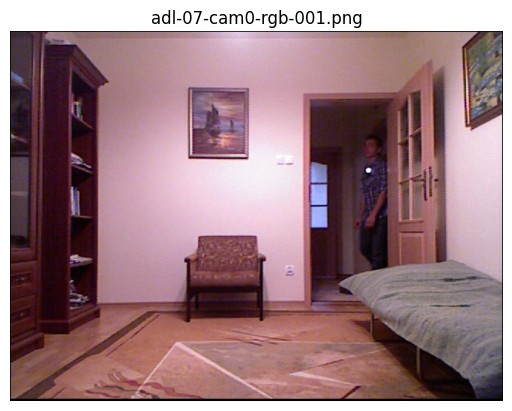

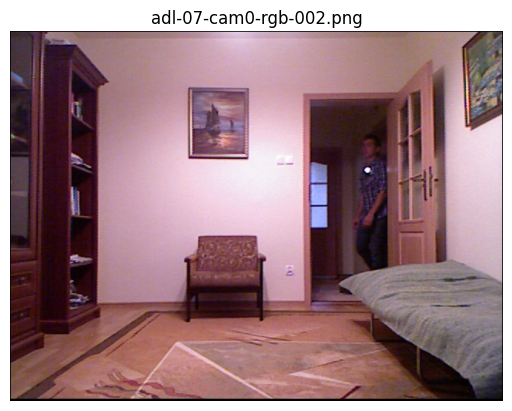

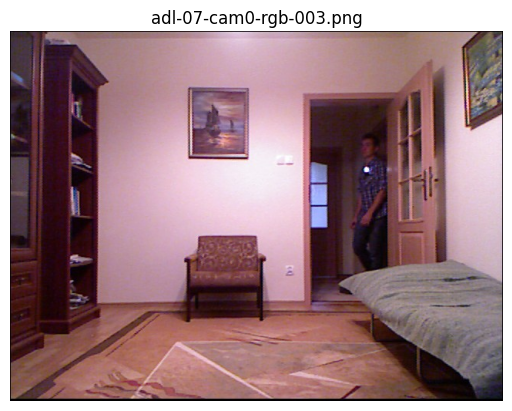

In [1]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

# Path to your dataset root
DATASET_ROOT = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset"

# Path to RGB camera-0 folder
cam0_path = os.path.join(
    DATASET_ROOT,
    "UR_fall_detection_dataset_cam0_rgb",
    "adl-07-cam0-rgb"
)

print("Dataset Path:", cam0_path)

# List all PNG files
image_paths = sorted(glob.glob(os.path.join(cam0_path, "*.png")))

print("Total Images Found:", len(image_paths))
print("Sample files:", image_paths[:5])

# Function to display images
def show_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

# Show first 3 images
for p in image_paths[:3]:
    show_image(p)

In [2]:
import cv2
import time
import glob
import os

# Dataset folder from Step 1
DATASET_ROOT = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset"
cam0_path = os.path.join(
    DATASET_ROOT,
    "UR_fall_detection_dataset_cam0_rgb",
    "adl-07-cam0-rgb"
)

# Collect image paths
image_paths = sorted(glob.glob(os.path.join(cam0_path, "*.png")))
print("Frames Loaded:", len(image_paths))

# ------------------------------
# BASIC PIPELINE STRUCTURE
# ------------------------------

def process_frame(frame):
    """
    Placeholder processing function.
    Step 3 will add Pose Estimation here.
    Step 4 will add Inpainting here.
    """
    # For now, return the original frame
    return frame

# ------------------------------
# PROCESS ALL FRAMES
# ------------------------------

fps_start_time = time.time()
frame_count = 0

processed_frames = []

for img_path in image_paths:
    frame = cv2.imread(img_path)

    if frame is None:
        continue

    # Step 2: Run through pipeline function
    output = process_frame(frame)
    processed_frames.append(output)

    frame_count += 1

fps_end_time = time.time()
elapsed = fps_end_time - fps_start_time
fps = frame_count / elapsed

print(f"Processed {frame_count} frames")
print(f"Pipeline FPS: {fps:.2f}")

Frames Loaded: 180
Processed 180 frames
Pipeline FPS: 37.63


In [6]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01


In [7]:
from ultralytics import YOLO

# Load lightweight YOLO Pose model
model = YOLO("yolov8n-pose.pt")

print("YOLOv8 Pose Model Loaded!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 Pose Model Loaded!



0: 480x640 1 person, 52.3ms
Speed: 5.4ms preprocess, 52.3ms inference, 31.7ms postprocess per image at shape (1, 3, 480, 640)


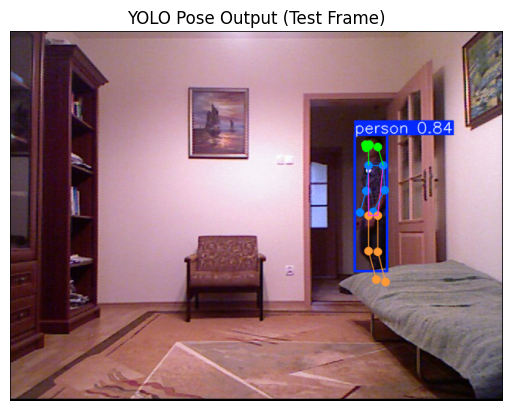

In [8]:
import matplotlib.pyplot as plt

test_img = cv2.imread(image_paths[0])
results = model(test_img)[0]

# Draw skeleton
annotated = results.plot()

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Pose Output (Test Frame)")
plt.show()

In [9]:
import time

keypoints_list = []
processed_frames = []

start = time.time()

def process_frame(frame):
    results = model(frame)[0]
    annotated = results.plot()

    # Extract keypoints if detected
    if results.keypoints:
        coords = results.keypoints.xy[0].tolist()  # 17 x (x,y)
    else:
        coords = None

    return annotated, coords

# Loop through dataset
for img_path in image_paths:
    frame = cv2.imread(img_path)
    annotated, coords = process_frame(frame)

    processed_frames.append(annotated)
    keypoints_list.append(coords)

end = time.time()

fps = len(image_paths) / (end - start)

print("Processed Frames:", len(processed_frames))
print("Average FPS:", fps)


0: 480x640 1 person, 7.9ms
Speed: 2.4ms preprocess, 7.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.8ms
Speed: 2.0ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.5ms
Speed: 1.9ms preprocess, 6.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 7.0ms
Speed: 2.1ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 7.0ms
Speed: 2.6ms preprocess, 7.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.7ms
Speed: 1.8ms preprocess, 6.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 7.1ms
Speed: 2.0ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x

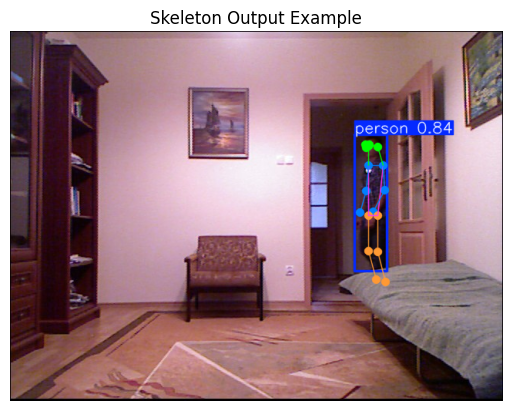

In [10]:
plt.imshow(cv2.cvtColor(processed_frames[0], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Skeleton Output Example")
plt.show()

In [11]:
import glob
import os
import re
import cv2
import matplotlib.pyplot as plt

cam0_path = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load all image paths
image_paths_alpha = sorted(glob.glob(os.path.join(cam0_path, "*.png")))

# Function to extract numeric part
def extract_num(path):
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

# Numeric sort
image_paths_num = sorted(image_paths_alpha, key=extract_num)

print("Alphabetical first 10:")
for p in image_paths_alpha[:10]:
    print(os.path.basename(p))

print("\nNumeric sorted first 10:")
for p in image_paths_num[:10]:
    print(os.path.basename(p))

Alphabetical first 10:
adl-07-cam0-rgb-001.png
adl-07-cam0-rgb-002.png
adl-07-cam0-rgb-003.png
adl-07-cam0-rgb-004.png
adl-07-cam0-rgb-005.png
adl-07-cam0-rgb-006.png
adl-07-cam0-rgb-007.png
adl-07-cam0-rgb-008.png
adl-07-cam0-rgb-009.png
adl-07-cam0-rgb-010.png

Numeric sorted first 10:
adl-07-cam0-rgb-001.png
adl-07-cam0-rgb-002.png
adl-07-cam0-rgb-003.png
adl-07-cam0-rgb-004.png
adl-07-cam0-rgb-005.png
adl-07-cam0-rgb-006.png
adl-07-cam0-rgb-007.png
adl-07-cam0-rgb-008.png
adl-07-cam0-rgb-009.png
adl-07-cam0-rgb-010.png


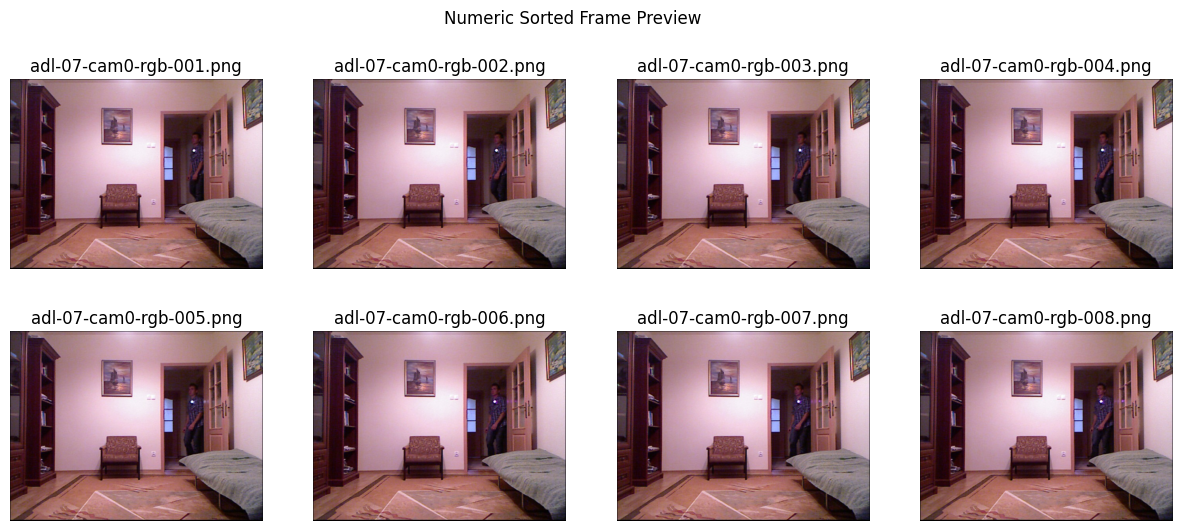

In [12]:
# Show first 8 frames numerically sorted
plt.figure(figsize=(15, 6))

for i in range(8):
    img = cv2.imread(image_paths_num[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(image_paths_num[i]))
    plt.axis("off")

plt.suptitle("Numeric Sorted Frame Preview")
plt.show()

In [13]:
import cv2

h, w, _ = cv2.imread(image_paths_num[0]).shape
video = cv2.VideoWriter("preview_50frames.mp4",
                        cv2.VideoWriter_fourcc(*"mp4v"),
                        20, (w, h))

for p in image_paths_num[:50]:  # only first 50 frames
    frame = cv2.imread(p)
    video.write(frame)

video.release()

print("Preview video saved: preview_50frames.mp4")

Preview video saved: preview_50frames.mp4


In [14]:
import cv2
import glob
import os
import re

cam0_path = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load all image paths
image_paths = glob.glob(os.path.join(cam0_path, "*.png"))

# Numeric sort
def extract_num(path):
    import re
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

image_paths = sorted(image_paths, key=extract_num)

# Create continuous video
sample = cv2.imread(image_paths[0])
h, w, _ = sample.shape

video = cv2.VideoWriter("raw_preview.mp4",
                        cv2.VideoWriter_fourcc(*"mp4v"),
                        20, (w, h))

for img_path in image_paths:
    frame = cv2.imread(img_path)
    video.write(frame)

video.release()

print("Video created: raw_preview.mp4")

Video created: raw_preview.mp4


In [16]:
import os
import glob
import re
import cv2
import matplotlib.pyplot as plt

cam0_path = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load all image paths
image_paths = glob.glob(os.path.join(cam0_path, "*.png"))

# Numeric sort
def extract_num(path):
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

image_paths = sorted(image_paths, key=extract_num)

print("Total frames:", len(image_paths))

Total frames: 180


In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n-pose.pt")  # fast & lightweight
print("YOLO Pose Model Loaded!")

YOLO Pose Model Loaded!


In [18]:
processed_frames = []
keypoints_all = []

for img_path in image_paths:
    frame = cv2.imread(img_path)
    results = model(frame)[0]

    # Draw skeleton
    annotated = results.plot()

    # Extract keypoints (x, y)
    if results.keypoints:
        kp = results.keypoints.xy[0].tolist()  # 17 keypoints
    else:
        kp = None

    processed_frames.append(annotated)
    keypoints_all.append(kp)

print("Processing complete!")


0: 480x640 1 person, 8.7ms
Speed: 1.6ms preprocess, 8.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.6ms
Speed: 1.6ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.2ms
Speed: 1.5ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.6ms
Speed: 1.7ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.1ms
Speed: 1.4ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.8ms
Speed: 1.7ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x

In [19]:
h, w, _ = processed_frames[0].shape

video = cv2.VideoWriter("skeleton_keypoints_video.mp4",
                        cv2.VideoWriter_fourcc(*"mp4v"),
                        20,
                        (w, h))

for frame in processed_frames:
    video.write(frame)

video.release()

print("Video saved as: skeleton_keypoints_video.mp4")

Video saved as: skeleton_keypoints_video.mp4
